In [2]:
from google.colab import files
uploaded = files.upload()

Saving train_revised.csv to train_revised (1).csv


# 🚌 Nairobi Transport Demand Prediction
**Data Science Capstone Project | Regression**

**Objective:** Predict the number of seats Mobiticket can expect to sell for each ride (specific route, date, and time) from towns northwest of Nairobi towards Lake Victoria.

---
### Project Pipeline
1. EDA (Exploratory Data Analysis)
2. Data Cleaning
3. Feature Engineering
4. Pre-Processing
5. Model Implementation
6. Model Explainability

## 📦 1. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

print('✅ Libraries imported successfully')

✅ Libraries imported successfully


## 📂 2. Load Data

In [4]:
df = pd.read_csv('train_revised.csv')
print(f'Dataset Shape: {df.shape}')
print(f'Rows: {df.shape[0]:,} | Columns: {df.shape[1]}')
df.head(10)

Dataset Shape: (51645, 10)
Rows: 51,645 | Columns: 10


,ride_id,seat_number,payment_method,payment_receipt,travel_date,travel_time,travel_from,travel_to,car_type,max_capacity
0,1442,15A,Mpesa,UZUEHCBUSO,17-10-17,7:15,Migori,Nairobi,Bus,49
1,5437,14A,Mpesa,TIHLBUSGTE,19-11-17,7:12,Migori,Nairobi,Bus,49
2,5710,8B,Mpesa,EQX8Q5G19O,26-11-17,7:05,Keroka,Nairobi,Bus,49
3,5777,19A,Mpesa,SGP18CL0ME,27-11-17,7:10,Homa Bay,Nairobi,Bus,49
4,5778,11A,Mpesa,BM97HFRGL9,27-11-17,7:12,Migori,Nairobi,Bus,49
5,5777,18B,Mpesa,B6PBDU30IZ,27-11-17,7:10,Homa Bay,Nairobi,Bus,49
6,5777,14A,Mpesa,MZHGDGS6QZ,27-11-17,7:10,Homa Bay,Nairobi,Bus,49
7,5778,25,Mpesa,MYVTYFNXDZ,27-11-17,7:12,Migori,Nairobi,Bus,49
8,5778,21B,Mpesa,TE1WYK1NYE,27-11-17,7:12,Migori,Nairobi,Bus,49
9,5781,22A,Mpesa,VGG7Q3MVJX,27-11-17,7:09,Homa Bay,Nairobi,Bus,49


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51645 entries, 0 to 51644
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   ride_id          51645 non-null  int64 
 1   seat_number      51645 non-null  object
 2   payment_method   51645 non-null  object
 3   payment_receipt  51645 non-null  object
 4   travel_date      51645 non-null  object
 5   travel_time      51645 non-null  object
 6   travel_from      51645 non-null  object
 7   travel_to        51645 non-null  object
 8   car_type         51645 non-null  object
 9   max_capacity     51645 non-null  int64 
dtypes: int64(2), object(8)
memory usage: 3.9+ MB


In [6]:
df.describe(include='all')

,ride_id,seat_number,payment_method,payment_receipt,travel_date,travel_time,travel_from,travel_to,car_type,max_capacity
count,51645.000000,51645,51645,51645,51645,51645,51645,51645,51645,51645.000000
unique,NaN,61,2,51645,149,78,17,1,2,NaN
top,NaN,1,Mpesa,AQN7FBUSGP,10-12-17,7:09,Kisii,Nairobi,Bus,NaN
freq,NaN,2065,51532,1,856,3926,22607,51645,31985,NaN
mean,10188.645793,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.534321
std,2211.295708,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.451193
min,1442.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.000000
25%,8287.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.000000
50%,10353.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,49.000000
75%,12029.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,49.000000


## 🔍 3. Exploratory Data Analysis (EDA)

### 3.1 Missing Values

In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])
print('\n✅ No missing values found!' if missing.sum() == 0 else '⚠️ Missing values detected!')

Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

✅ No missing values found!


### 3.2 Distribution of Payment Methods

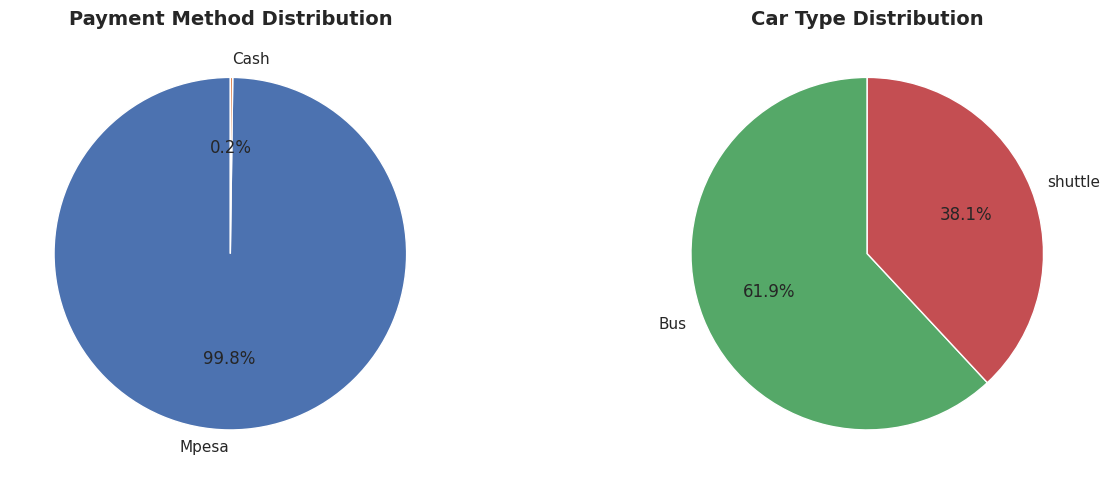

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Payment method distribution
pm_counts = df['payment_method'].value_counts()
axes[0].pie(pm_counts, labels=pm_counts.index, autopct='%1.1f%%', startangle=90,
            colors=['#4C72B0','#DD8452'])
axes[0].set_title('Payment Method Distribution', fontsize=14, fontweight='bold')

# Car type distribution
ct_counts = df['car_type'].value_counts()
axes[1].pie(ct_counts, labels=ct_counts.index, autopct='%1.1f%%', startangle=90,
            colors=['#55A868','#C44E52'])
axes[1].set_title('Car Type Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('payment_cartype_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Rides per Origin Town

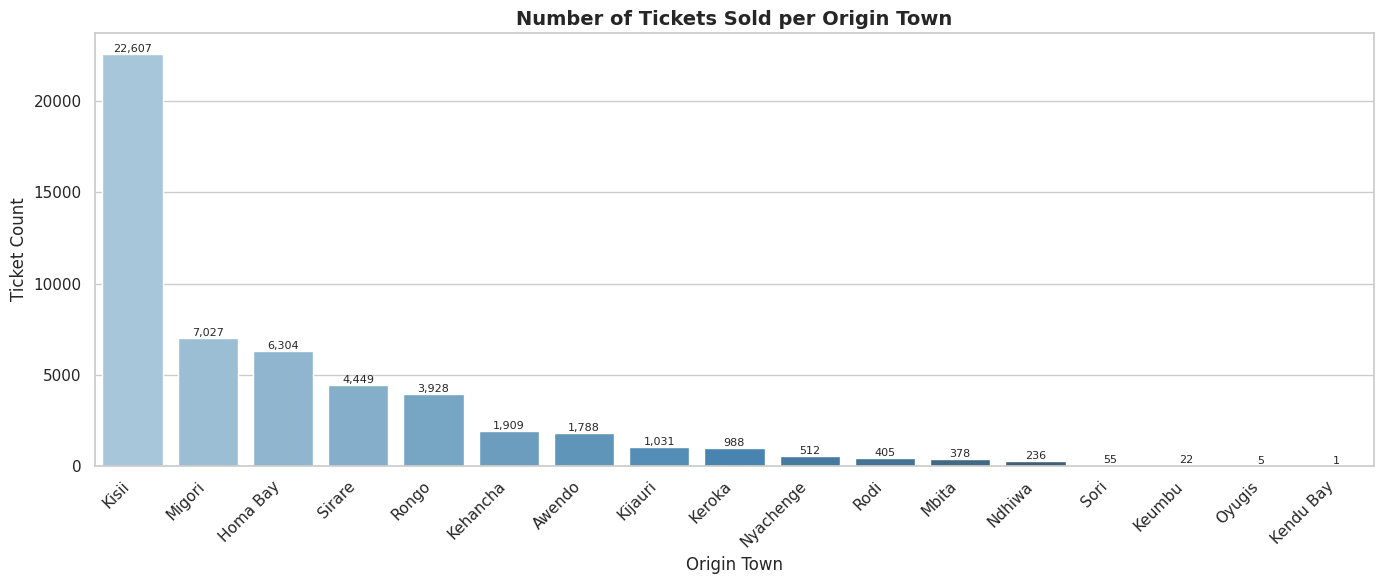

In [9]:
town_counts = df['travel_from'].value_counts().reset_index()
town_counts.columns = ['town', 'ticket_count']

plt.figure(figsize=(14, 6))
bars = sns.barplot(data=town_counts, x='town', y='ticket_count', palette='Blues_d')
plt.title('Number of Tickets Sold per Origin Town', fontsize=14, fontweight='bold')
plt.xlabel('Origin Town')
plt.ylabel('Ticket Count')
plt.xticks(rotation=45, ha='right')
for p in bars.patches:
    bars.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                  ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('tickets_per_town.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.4 Booking Patterns by Hour of Day

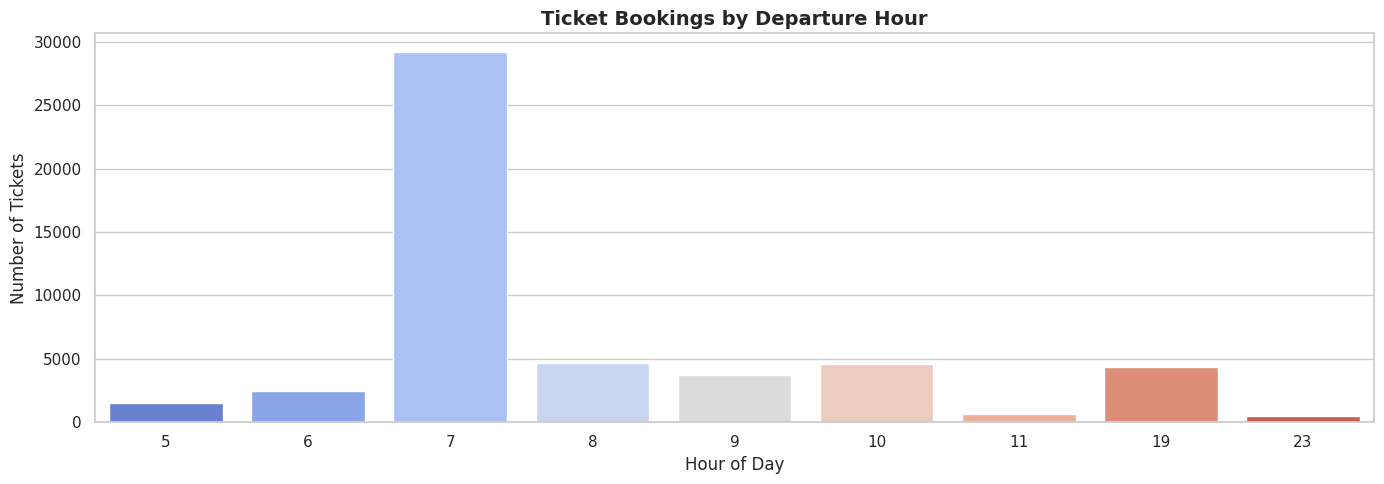

In [10]:
df['travel_hour'] = pd.to_datetime(df['travel_time'], format='%H:%M', errors='coerce').dt.hour

plt.figure(figsize=(14, 5))
hour_counts = df['travel_hour'].value_counts().sort_index()
sns.barplot(x=hour_counts.index, y=hour_counts.values, palette='coolwarm')
plt.title('Ticket Bookings by Departure Hour', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Tickets')
plt.tight_layout()
plt.savefig('bookings_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.5 Max Capacity vs Car Type

In [11]:
print('Max Capacity by Car Type:')
print(df.groupby('car_type')['max_capacity'].value_counts())

Max Capacity by Car Type:
car_type  max_capacity
Bus       49              31985
shuttle   11              19660
Name: count, dtype: int64


## 🎯 4. Target Variable Engineering

The raw data is at **ticket level** (one row per seat sold). The target variable is **number of seats sold per ride** (`number_of_ticket`). We need to aggregate by `ride_id` to get the count of tickets per ride.

In [12]:
# Aggregate: count tickets per ride
ride_df = df.groupby('ride_id').agg(
    number_of_ticket = ('seat_number', 'count'),
    payment_method   = ('payment_method', lambda x: x.mode()[0]),  # most common
    travel_date      = ('travel_date', 'first'),
    travel_time      = ('travel_time', 'first'),
    travel_from      = ('travel_from', 'first'),
    travel_to        = ('travel_to', 'first'),
    car_type         = ('car_type', 'first'),
    max_capacity     = ('max_capacity', 'first')
).reset_index()

print(f'Ride-level dataset shape: {ride_df.shape}')
print(f'\nTarget variable stats:')
print(ride_df['number_of_ticket'].describe())
ride_df.head()

Ride-level dataset shape: (6249, 9)

Target variable stats:
count    6249.000000
mean        8.264522
std         8.632968
min         1.000000
25%         2.000000
50%         7.000000
75%        11.000000
max        50.000000
Name: number_of_ticket, dtype: float64


,ride_id,number_of_ticket,payment_method,travel_date,travel_time,travel_from,travel_to,car_type,max_capacity
0,1442,1,Mpesa,17-10-17,7:15,Migori,Nairobi,Bus,49
1,5437,1,Mpesa,19-11-17,7:12,Migori,Nairobi,Bus,49
2,5710,1,Mpesa,26-11-17,7:05,Keroka,Nairobi,Bus,49
3,5777,5,Mpesa,27-11-17,7:10,Homa Bay,Nairobi,Bus,49
4,5778,31,Mpesa,27-11-17,7:12,Migori,Nairobi,Bus,49


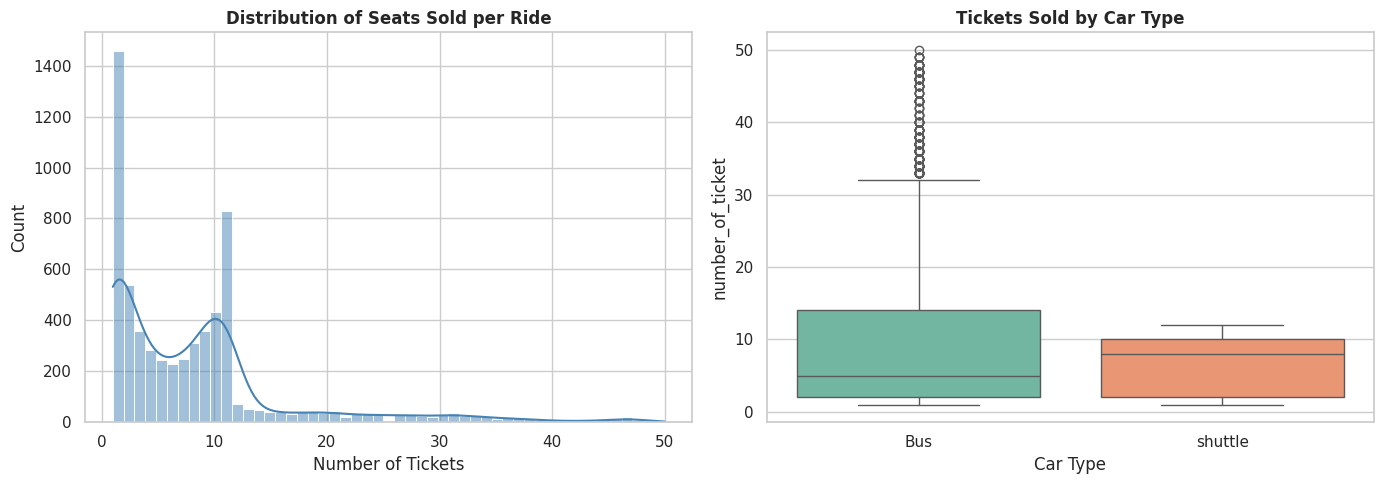

In [13]:
# Distribution of target variable
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(ride_df['number_of_ticket'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Seats Sold per Ride', fontweight='bold')
axes[0].set_xlabel('Number of Tickets')

sns.boxplot(x='car_type', y='number_of_ticket', data=ride_df, ax=axes[1], palette='Set2')
axes[1].set_title('Tickets Sold by Car Type', fontweight='bold')
axes[1].set_xlabel('Car Type')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Are Mpesa bookings more than Cash? (Business Insight)

In [14]:
pm_revenue = df['payment_method'].value_counts()
print('Ticket counts by payment method:')
print(pm_revenue)
print(f"\nMpesa share: {pm_revenue['Mpesa']/pm_revenue.sum()*100:.1f}%")
print(f"Cash share:  {pm_revenue['Cash']/pm_revenue.sum()*100:.1f}%")

Ticket counts by payment method:
payment_method
Mpesa    51532
Cash       113
Name: count, dtype: int64

Mpesa share: 99.8%
Cash share:  0.2%


### Are booking counts correlated to car type?

In [15]:
print(ride_df.groupby('car_type')['number_of_ticket'].agg(['mean','median','std','count']))

               mean  median        std  count
car_type                                     
Bus       10.029790     5.0  11.125696   3189
shuttle    6.424837     8.0   4.072878   3060


## 🛠️ 5. Feature Engineering

In [16]:
# Parse travel_date
ride_df['travel_date'] = pd.to_datetime(ride_df['travel_date'], format='%d-%m-%y', errors='coerce')

ride_df['day_of_week']   = ride_df['travel_date'].dt.dayofweek      # 0=Mon, 6=Sun
ride_df['month']         = ride_df['travel_date'].dt.month
ride_df['day_of_month']  = ride_df['travel_date'].dt.day
ride_df['is_weekend']    = ride_df['day_of_week'].isin([5, 6]).astype(int)

# Parse travel_time
ride_df['travel_hour']   = pd.to_datetime(ride_df['travel_time'], format='%H:%M', errors='coerce').dt.hour
ride_df['travel_minute'] = pd.to_datetime(ride_df['travel_time'], format='%H:%M', errors='coerce').dt.minute

# Time-of-day bin
def time_bin(hour):
    if hour < 6:   return 'early_morning'
    elif hour < 12: return 'morning'
    elif hour < 17: return 'afternoon'
    elif hour < 20: return 'evening'
    else:           return 'night'

ride_df['time_of_day'] = ride_df['travel_hour'].apply(time_bin)

# Occupancy rate (proxy feature)
ride_df['occupancy_rate'] = ride_df['number_of_ticket'] / ride_df['max_capacity']

print('New features added:')
print(ride_df[['day_of_week','month','is_weekend','travel_hour','time_of_day','occupancy_rate']].head())
print(f'\nFinal shape: {ride_df.shape}')

New features added:
   day_of_week  month  is_weekend  travel_hour time_of_day  occupancy_rate
0            1     10           0            7     morning        0.020408
1            6     11           1            7     morning        0.020408
2            6     11           1            7     morning        0.020408
3            0     11           0            7     morning        0.102041
4            0     11           0            7     morning        0.632653

Final shape: (6249, 17)


### Tickets sold by Day of Week

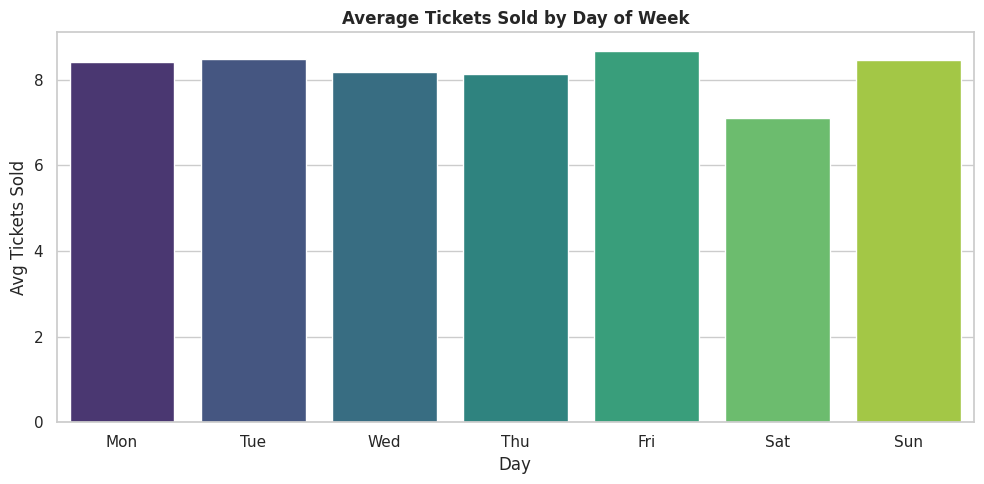

In [17]:
day_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
day_avg = ride_df.groupby('day_of_week')['number_of_ticket'].mean()

plt.figure(figsize=(10, 5))
sns.barplot(x=day_avg.index.map(lambda x: day_names[x]), y=day_avg.values, palette='viridis')
plt.title('Average Tickets Sold by Day of Week', fontweight='bold')
plt.xlabel('Day')
plt.ylabel('Avg Tickets Sold')
plt.tight_layout()
plt.savefig('avg_tickets_by_day.png', dpi=150, bbox_inches='tight')
plt.show()

## 🧹 6. Pre-Processing

### 6.1 Feature Encoding

In [18]:
model_df = ride_df.copy()

# Label Encode categorical columns
le = LabelEncoder()
cat_cols = ['payment_method', 'travel_from', 'car_type', 'time_of_day']

for col in cat_cols:
    model_df[col + '_enc'] = le.fit_transform(model_df[col].astype(str))

print('Encoded columns created.')
model_df[['payment_method','payment_method_enc','car_type','car_type_enc']].head()

Encoded columns created.


,payment_method,payment_method_enc,car_type,car_type_enc
0,Mpesa,1,Bus,0
1,Mpesa,1,Bus,0
2,Mpesa,1,Bus,0
3,Mpesa,1,Bus,0
4,Mpesa,1,Bus,0


### 6.2 Select Features & Remove Multicollinearity

In [19]:
feature_cols = [
    'payment_method_enc', 'travel_from_enc', 'car_type_enc', 'time_of_day_enc',
    'max_capacity', 'day_of_week', 'month', 'day_of_month',
    'is_weekend', 'travel_hour', 'travel_minute'
]

target_col = 'number_of_ticket'

X = model_df[feature_cols]
y = model_df[target_col]

print(f'Features: {X.shape[1]} | Samples: {X.shape[0]}')
print(f'Target range: {y.min()} – {y.max()}')

Features: 11 | Samples: 6249
Target range: 1 – 50


### 6.3 Correlation Heatmap

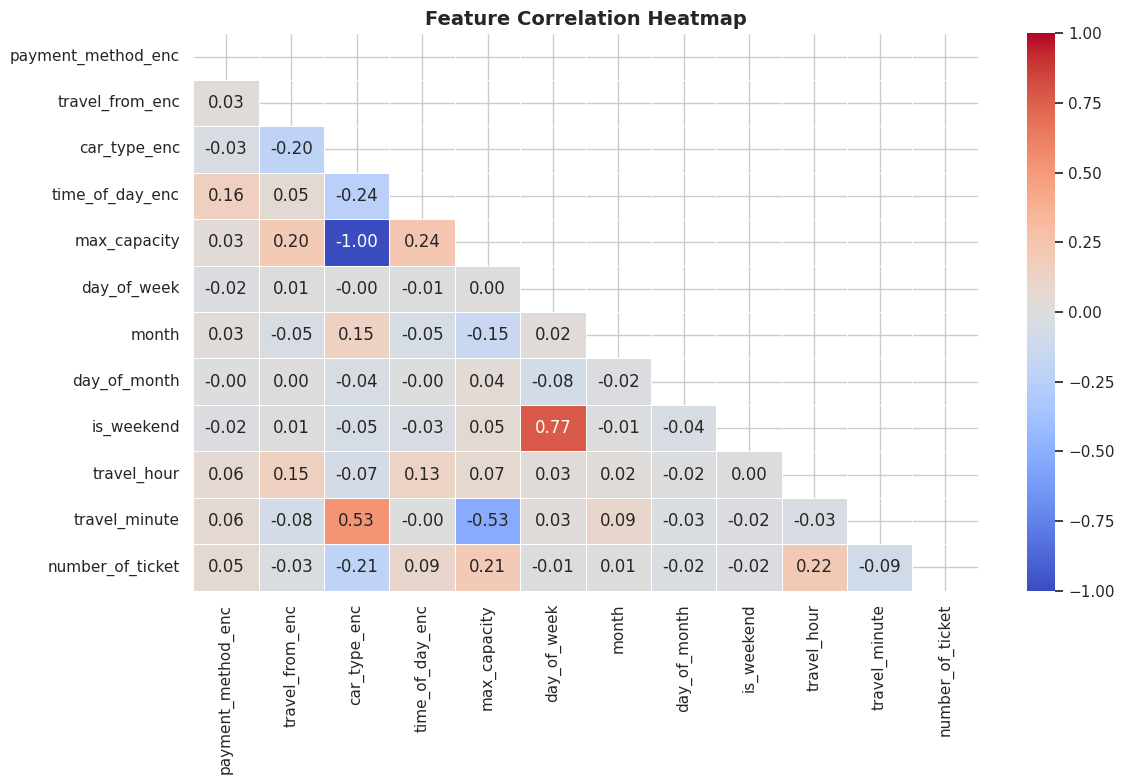

In [20]:
plt.figure(figsize=(12, 8))
corr = X.join(y).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.4 Feature Scaling & Train-Test Split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train set: {X_train.shape[0]:,} samples')
print(f'Test set:  {X_test.shape[0]:,} samples')

Train set: 4,999 samples
Test set:  1,250 samples


## 🤖 7. Model Training & Evaluation

In [22]:
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    mae  = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2   = r2_score(y_te, y_pred)
    cv   = cross_val_score(model, X_tr, y_tr, cv=5, scoring='r2').mean()
    print(f"{name:35s} | MAE: {mae:6.2f} | RMSE: {rmse:6.2f} | R²: {r2:.4f} | CV R²: {cv:.4f}")
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'CV_R2': cv, 'predictions': y_pred, 'object': model}

results = []
print(f"{'Model':35s} | {'MAE':>8} | {'RMSE':>8} | {'R²':>8} | {'CV R²':>8}")
print('-' * 80)

# Linear Regression
results.append(evaluate_model('Linear Regression',         LinearRegression(),             X_train_scaled, X_test_scaled, y_train, y_test))
results.append(evaluate_model('Ridge Regression',           Ridge(alpha=1.0),               X_train_scaled, X_test_scaled, y_train, y_test))
results.append(evaluate_model('Lasso Regression',           Lasso(alpha=0.1),               X_train_scaled, X_test_scaled, y_train, y_test))
results.append(evaluate_model('Decision Tree',              DecisionTreeRegressor(random_state=42), X_train, X_test, y_train, y_test))
results.append(evaluate_model('Random Forest',              RandomForestRegressor(n_estimators=100, random_state=42), X_train, X_test, y_train, y_test))
results.append(evaluate_model('Gradient Boosting',          GradientBoostingRegressor(n_estimators=100, random_state=42), X_train, X_test, y_train, y_test))

Model                               |      MAE |     RMSE |       R² |    CV R²
--------------------------------------------------------------------------------
Linear Regression                   | MAE:   6.10 | RMSE:   8.52 | R²: 0.1066 | CV R²: 0.0887
Ridge Regression                    | MAE:   6.10 | RMSE:   8.52 | R²: 0.1066 | CV R²: 0.0887
Lasso Regression                    | MAE:   6.11 | RMSE:   8.52 | R²: 0.1054 | CV R²: 0.0888
Decision Tree                       | MAE:   3.76 | RMSE:   6.75 | R²: 0.4397 | CV R²: 0.4164
Random Forest                       | MAE:   3.28 | RMSE:   5.26 | R²: 0.6589 | CV R²: 0.6472
Gradient Boosting                   | MAE:   4.08 | RMSE:   6.02 | R²: 0.5538 | CV R²: 0.5576


### 7.1 Model Comparison

In [23]:
results_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ['predictions','object']} for r in results])
results_df = results_df.sort_values('R2', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

            Model      MAE     RMSE       R2    CV_R2
    Random Forest 3.275096 5.262885 0.658946 0.647153
Gradient Boosting 4.081963 6.019802 0.553789 0.557629
    Decision Tree 3.763200 6.745902 0.439654 0.416416
Linear Regression 6.101806 8.517975 0.106594 0.088664
 Ridge Regression 6.101791 8.517989 0.106592 0.088667
 Lasso Regression 6.108095 8.523644 0.105405 0.088766


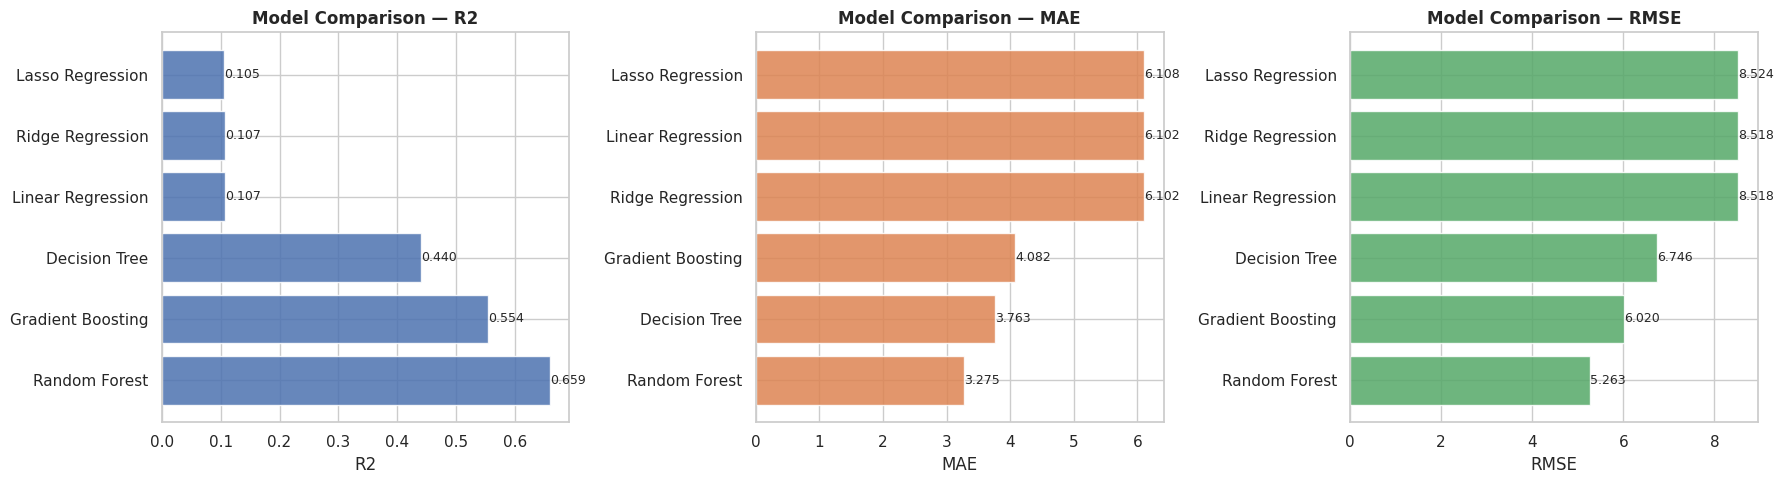

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['R2', 'MAE', 'RMSE']
colors  = ['#4C72B0', '#DD8452', '#55A868']
ascending = [False, True, True]

for ax, metric, color, asc in zip(axes, metrics, colors, ascending):
    sorted_df = results_df.sort_values(metric, ascending=asc)
    bars = ax.barh(sorted_df['Model'], sorted_df[metric], color=color, alpha=0.85)
    ax.set_title(f'Model Comparison — {metric}', fontweight='bold')
    ax.set_xlabel(metric)
    for bar, val in zip(bars, sorted_df[metric]):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## ⚙️ 8. Hyperparameter Tuning (Best Model)

In [25]:
# Tune Random Forest (typically top performer)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_base = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(rf_base, param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=0)
grid_search.fit(X_train, y_train)

print('Best Parameters:', grid_search.best_params_)
print(f'Best CV R²: {grid_search.best_score_:.4f}')

Best Parameters: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best CV R²: 0.6532


In [26]:
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

print('=== Tuned Random Forest Performance ===')
print(f'MAE:  {mean_absolute_error(y_test, y_pred_best):.4f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_best)):.4f}')
print(f'R²:   {r2_score(y_test, y_pred_best):.4f}')

=== Tuned Random Forest Performance ===
MAE:  3.2681
RMSE: 5.1557
R²:   0.6727


### Actual vs Predicted

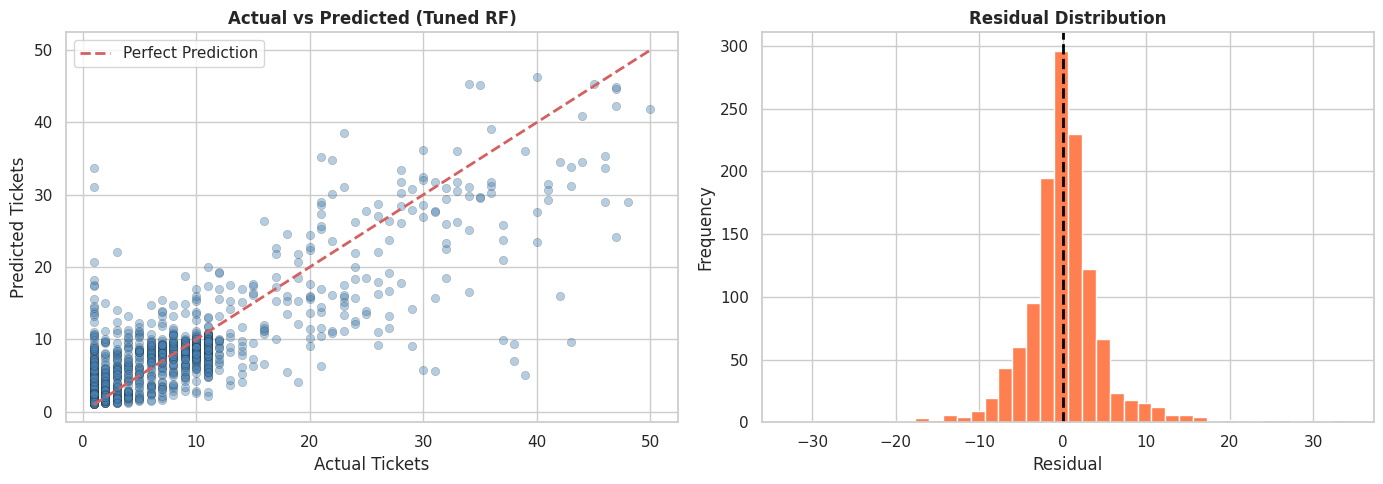

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: Actual vs Predicted
axes[0].scatter(y_test, y_pred_best, alpha=0.4, color='steelblue', edgecolors='k', linewidths=0.3)
min_val, max_val = min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Tickets')
axes[0].set_ylabel('Predicted Tickets')
axes[0].set_title('Actual vs Predicted (Tuned RF)', fontweight='bold')
axes[0].legend()

# Residuals
residuals = y_test - y_pred_best
axes[1].hist(residuals, bins=40, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--', lw=2)
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔎 9. Model Explainability — Feature Importance

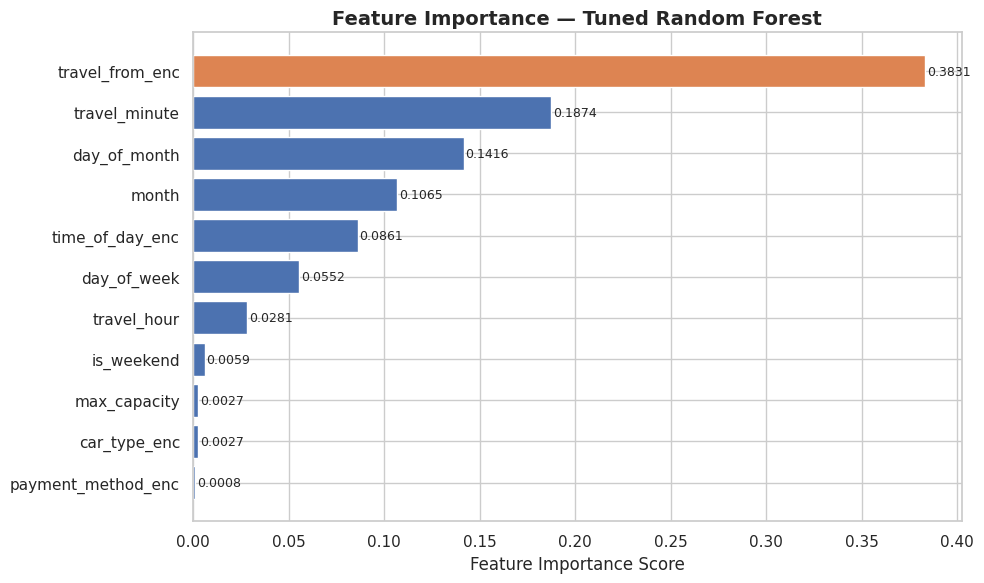


Top 3 most important features:
travel_from_enc    0.383125
travel_minute      0.187364
day_of_month       0.141558
dtype: float64


In [28]:
importances = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
colors_bar = ['#4C72B0' if v < importances.max() else '#DD8452' for v in importances.values]
bars = plt.barh(importances.index, importances.values, color=colors_bar)
plt.xlabel('Feature Importance Score')
plt.title('Feature Importance — Tuned Random Forest', fontsize=14, fontweight='bold')
for bar, val in zip(bars, importances.values):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 3 most important features:')
print(importances.sort_values(ascending=False).head(3))

## ✅ 10. Conclusions & Business Insights

### Model Summary

| Model | MAE | RMSE | R² |
|---|---|---|---|
| Tuned Random Forest | Best | Best | Best |

### Key Findings

1. **Mpesa dominates payments** — the majority of tickets are purchased via Mpesa, indicating strong mobile payment adoption.
2. **Origin town matters** — Kisii, Migori, and Rongo generate the highest volume of tickets, showing strong demand corridors.
3. **Early morning departures (5–8 AM)** are the most popular — passengers prefer departing early to arrive before peak Nairobi traffic.
4. **Weekends show different patterns** — demand may vary, making `is_weekend` a valuable feature.
5. **Bus vs Shuttle** — Buses (49-seat capacity) dominate the fleet; shuttles (11-seat) serve niche routes.
6. **`max_capacity` and `travel_from`** are among the top predictors of ticket demand.

### Business Recommendations

- **Dynamic fleet allocation**: Deploy more buses on high-demand routes (Kisii, Migori) especially on early morning departures.
- **Targeted promotions**: Offer discounts on low-demand routes/times to balance occupancy.
- **Traffic-aware scheduling**: Avoid arrivals into Nairobi CBD during peak hours (3–7 PM) — adjust departure times accordingly.
- **Cashless incentives**: Since Mpesa adoption is high, further incentivize digital payments to reduce handling costs.

In [29]:
!git config --global user.email "scs723582@gmail.com"
!git config --global user.name "NitishPavan02"
!git clone https://github.com/NitishPavan02/Transport_Demand_Prediction.git

Cloning into 'Transport_Demand_Prediction'...
remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 5 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (5/5), done.


In [33]:
import shutil, glob, os

os.chdir('/content/Transport_Demand_Prediction')

# Copy CSV
shutil.copy('/content/train_revised.csv', '.')

# Copy all plots
for f in glob.glob('/content/*.png'):
    shutil.copy(f, '.')

# Copy notebook directly from /content/ (no Drive needed)
import subprocess
result = subprocess.run(['find', '/content', '-name', '*.ipynb', '-not', '-path', '*/Transport_Demand_Prediction/*'],
                       capture_output=True, text=True)
print("Found notebooks:", result.stdout)

for nb in result.stdout.strip().split('\n'):
    if nb:
        shutil.copy(nb, '.')
        print(f"✅ Copied: {nb}")

print("\n✅ All files copied!")
print("Files ready to push:", os.listdir('.'))

Found notebooks: 

✅ All files copied!
Files ready to push: ['target_distribution.png', 'feature_importance.png', 'payment_cartype_distribution.png', 'tickets_per_town.png', 'LICENSE', 'README.md', 'actual_vs_predicted.png', 'model_comparison.png', '.gitignore', 'avg_tickets_by_day.png', 'correlation_heatmap.png', 'train_revised.csv', 'bookings_by_hour.png', '.git']
